# Predicting Corvus corone

## A.S.K
- Matin
- Mohamad
- Dima

----

# 1. Business Understanding

## 1.1 Problem description


Large amounts of citizen-science data about Corvus corone are available through biodiversity observation platforms. These datasets contain valuable information about when and where observations are reported across different locations and time periods. However, the distribution of observations is highly uneven. Some locations and periods contain many observations, while others contain very few.

Observation activity may be influenced by several factors, including weather conditions, seasonal changes, geographic location, and human observation behavior. Because the dataset is based on citizen-science reports, individual observations may be noisy and influenced by reporting effort.

Currently, there is no simple method for estimating when and where high Corvus corone observation activity is likely to occur. A predictive model may help identify patterns in observation activity and improve understanding of how environmental and temporal factors influence citizen-science reporting data.

## 1.2 Business objective

The objective of this project is to support biodiversity monitoring by analyzing patterns in Corvus corone observation activity using citizen-science data.

The project aims to investigate how spatial, temporal, and weather-related factors influence whether Corvus corone observation activity is high or low during a specific time period and location.

By identifying these patterns, the project may help researchers better understand reporting trends in biodiversity datasets and improve the interpretation of citizen-science observation data.

## 1.3 Data Mining Goal (DMG)

The data mining goal of this project is to build and evaluate a binary classification model that predicts whether Corvus corone observation activity will be high or low for a given location and time period.

The model will use spatial, temporal, and weather-related variables as input features. These may include location information, season, temperature, rainfall, humidity, and wind speed.

The target variable will represent the level of Corvus corone observation activity:

- 0 = low Corvus corone observation activity
- 1 = high Corvus corone observation activity

Observation activity will be determined using the number of reported observations within a selected spatiotemporal context. A threshold value will later be defined during data preparation to separate high and low activity levels.

The model performance will be compared against a naive majority-class baseline to determine whether the model adds predictive value.

## 1.4 Success criteria

The model will be considered successful if it performs better than a naive majority-class baseline on unseen test data.

Because the dataset may be imbalanced, accuracy alone is not sufficient for evaluating model performance. Therefore, the project will primarily focus on AUC-ROC, F1-score, precision, and recall.

- Primary Success Criteria
- The model achieves an AUC-ROC score of at least 0.60 on the test set.
- The model achieves a higher F1-score than the majority-class baseline.
- Secondary Success Criteria
- The model maintains balanced predictive performance between high and low observation activity classes.
- The model generalizes consistently on unseen test data without severe overfitting.

These criteria make the project measurable because the model performance can be quantitatively evaluated and directly compared using fixed evaluation metrics.

## 1.5 Research Question

To what extent can spatial, temporal, and weather-related factors predict high or low Corvus corone observation activity in citizen-science data?


## 1.6 Possible External Data Sources

Possible external data sources that may improve prediction performance include:

- Weather data
- Temperature
- Rainfall
- Seasonal information
- Humidity
- Wind speed
- Land cover information

These external variables may help explain variation in Corvus corone observation activity across locations and time periods.

## 1.7 Why Classification?

A classification approach is suitable because the target variable contains two classes:

- low Corvus corone observation activity
- high Corvus corone observation activity

The objective is to predict which class a specific location and time period belongs to based on spatial, temporal, and weather-related features.

Binary classification is appropriate because the prediction output consists of two possible outcomes (0 or 1).

## 1.8 Weather Data Source

Weather data is included as an external data source using KNMI daily weather observations. Weather conditions are relevant because they may influence both Corvus corone activity and citizen-science observation behavior.

For example, temperature, precipitation, humidity, and wind speed may affect whether Corvus corone is active, visible, or likely to be reported by citizen scientists.

The selected KNMI variables are:

- TG = average daily temperature
- TN = minimum daily temperature
- TX = maximum daily temperature
- RH = daily precipitation
- UG = average relative humidity
- FG = average wind speed

The weather data was collected from KNMI weather station “260 De Bilt” for the period between 2010 and 2025. These variables may later be merged with the Corvus corone dataset based on date information.

----

# 2. Data Understanding

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import contextily as ctx
from scipy.ndimage import gaussian_filter

## 2.1 Dataset overview

We load the dataset using `pandas.read_csv()`. The file contains observations of Corvus corone across different locations and dates. After loading, we check the number of rows and columns, and preview the first few rows to understand the data structure.

In [28]:
# Load dataset
df = pd.read_csv(
    "../data/raw/Corvus_corone.csv",
    low_memory=False
)

df.head()
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
df.columns

Rows: 12558786
Columns: 6


Index(['decimalLatitude', 'decimalLongitude', 'eventDate',
       'total_observations', 'speciesgroup_observations', 'Corvus corone'],
      dtype='str')

## 2.2 Variable descriptions

Below is a description of each column in the dataset:

| Column | Description |
|--------|-------------|
| `decimalLatitude` | Latitude coordinate of the observation location (WGS84) |
| `decimalLongitude` | Longitude coordinate of the observation location (WGS84) |
| `eventDate` | Date of the observation in YYYY-MM-DD format |
| `total_observations` | Total number of bird observations (all species) at this location and date – indicates sampling effort |
| `speciesgroup_observations` | Number of observations belonging to the same species group (potentially corvids or related families) – a more specific sampling effort |
| `Corvus corone` | Corvus corone observation count for a location and date. This column is used to create a binary target where 0 = low observation activity and 1 = high observation activity. |

In [29]:
column_descriptions = pd.DataFrame({
    "Column": df.columns,
    "Description": [
        "Latitude coordinate of the observation location" if col == "decimalLatitude" else
        "Longitude coordinate of the observation location" if col == "decimalLongitude" else
        "Date of the observation" if col == "eventDate" else
        "Total number of observations at this location/date, used as sampling effort" if col == "total_observations" else
        "Number of observations from the same species group, used as specific sampling effort" if col == "speciesgroup_observations" else
        "Corvus corone observation count, used to create the low/high activity target" if "Corvus" in col else
        "Additional feature"
        for col in df.columns
    ]
})

column_descriptions

,Column,Description
0,decimalLatitude,Latitude coordinate of the observation location
1,decimalLongitude,Longitude coordinate of the observation location
2,eventDate,Date of the observation
3,total_observations,Total number of observations at this location/...
4,speciesgroup_observations,Number of observations from the same species g...
5,Corvus corone,"Corvus corone observation count, used to creat..."


## 2.3 Statistical summary

We examine the data types and basic statistics of numerical columns using `df.info()` and `df.describe()`.

**Observations:**
- All columns except `eventDate` are numeric.
- `decimalLatitude` and `decimalLongitude` appear to have limited unique values in the sample, but the full dataset may cover a wider geographic range.
- `total_observations` and `speciesgroup_observations` range from 0 to moderately high values, with many zeros.
- The target column `Corvus corone` is stored as an object (string) initially, which we later convert to numeric.
  

In [30]:
print("Data types and memory:")
df.info()

print("\nDescriptive statistics for numerical columns:")
df.describe()

Data types and memory:
<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Corvus corone              str    
dtypes: float64(3), int64(1), str(2)
memory usage: 574.9 MB

Descriptive statistics for numerical columns:


,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,8.056834e+00,4.314087e+00
std,6.647267e-01,8.779710e-01,4.821959e+01,1.610809e+01
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,2.000000e+00
max,5.350000e+01,5.340000e+01,1.000390e+05,2.781000e+03


## 2.4 Missing values

We check for missing data in each column.

**Result:** Only `total_observations` contains a single missing value (0.0% of the dataset). All other columns have complete data. Since the missing proportion is negligible, we can simply drop that row or fill with a reasonable value (e.g., 0) without affecting the analysis.

In [31]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing_values

,Missing values,Missing percentage
decimalLatitude,0,0.0
decimalLongitude,0,0.0
eventDate,0,0.0
total_observations,1,0.0
speciesgroup_observations,0,0.0
Corvus corone,0,0.0


## 2.5 Target distribution

The target variable `Corvus corone` contains the number of Corvus corone observations for each location and date. For this exploratory classification setup, we convert it into a binary low/high activity target using a simple threshold:

- **0** = Low observation activity (`Corvus corone` = 0)
- **1** = High observation activity (`Corvus corone` > 0)

**Class counts and percentages:**

- Low observation activity: ~95.13% of the data
- High observation activity: ~4.87% of the data

The dataset is **highly imbalanced**, with low observation activity dominating. This imbalance will influence our modeling strategy and means we will need to use metrics like F1-score and recall rather than accuracy, and consider techniques such as resampling or class weighting. The threshold can be refined later during data preparation if a stricter definition of high activity is needed.

In [32]:
target_col = "Corvus corone"

# Convert target column to numeric
df[target_col] = pd.to_numeric(df[target_col], errors="coerce").fillna(0)

# Create preliminary binary target for low/high observation activity
df["target_binary"] = (df[target_col] > 0).astype(int)

class_distribution = df["target_binary"].value_counts().rename(index={
    0: "Low activity",
    1: "High activity"
})

class_distribution

target_binary
Low activity     11946959
High activity      611827
Name: count, dtype: int64

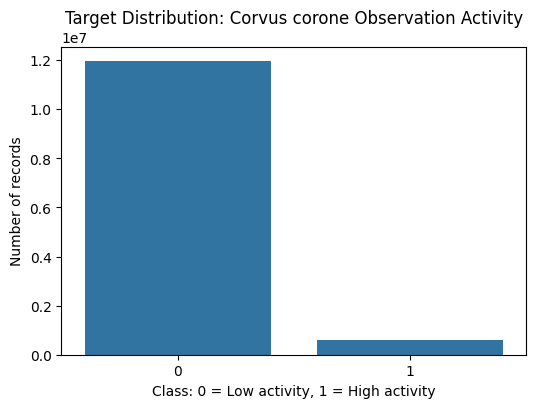

target_binary
Low activity     95.13
High activity     4.87
Name: proportion, dtype: float64

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["target_binary"])
plt.title("Target Distribution: Corvus corone Observation Activity")
plt.xlabel("Class: 0 = Low activity, 1 = High activity")
plt.ylabel("Number of records")
plt.show()

class_percentage = (
    df["target_binary"]
    .value_counts(normalize=True)
    .rename(index={0: "Low activity", 1: "High activity"})
    * 100
).round(2)
class_percentage

## 2.6 Spatial Distribution Map

To better understand the spatial distribution of Corvus corone observations, we visualize the locations where the species was recorded across the Netherlands. This map provides an initial overview of geographic observation density and may help identify possible spatial clustering or sampling bias in the dataset.

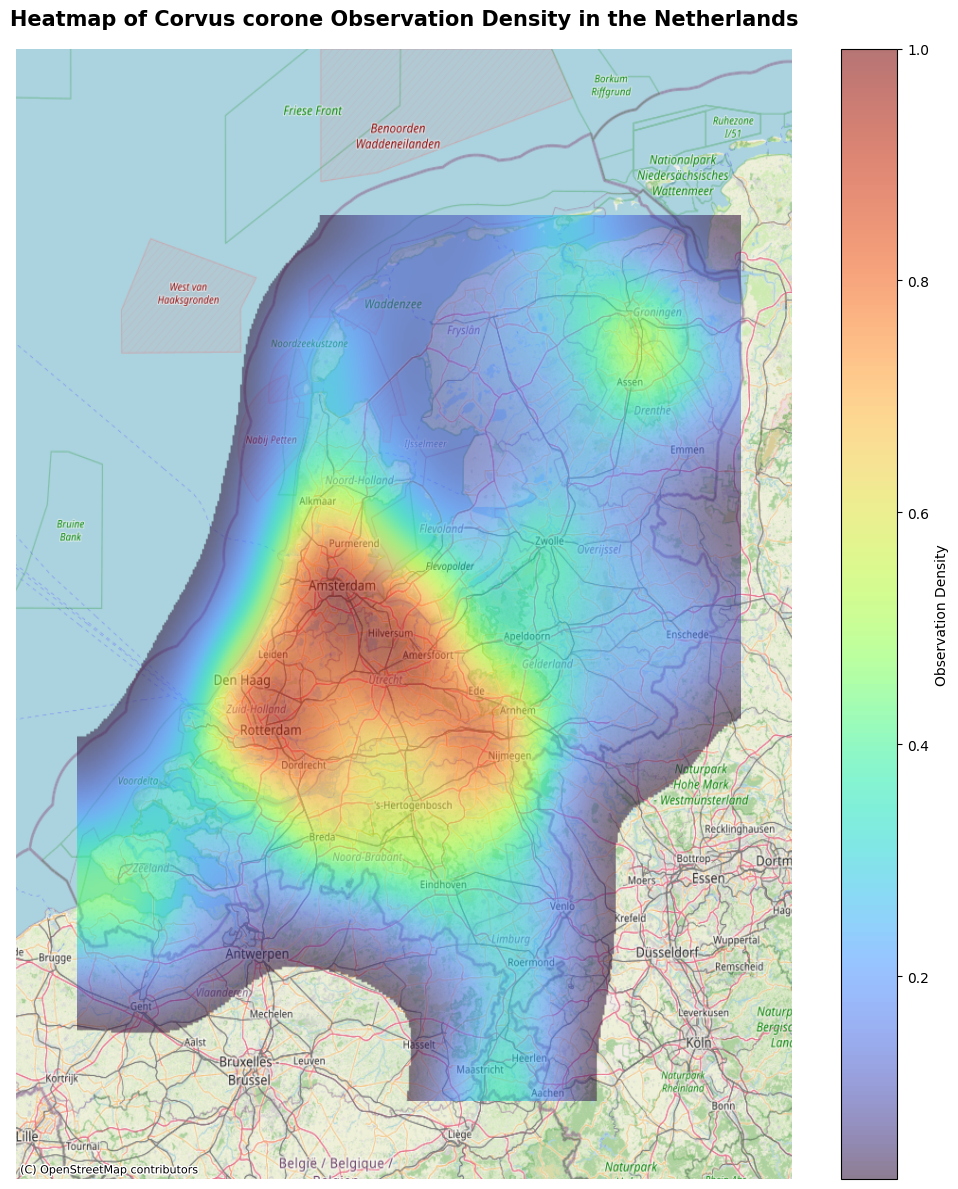

In [34]:
# 1. Prepare data
df["Corvus corone"] = pd.to_numeric(df["Corvus corone"], errors="coerce").fillna(0)

crow_df = df[df["Corvus corone"] > 0].copy()
crow_df = crow_df.dropna(subset=["decimalLatitude", "decimalLongitude"])

crow_df = crow_df[
    (crow_df["decimalLatitude"].between(50.5, 54.0)) &
    (crow_df["decimalLongitude"].between(3.0, 7.5))
].copy()

crow_df = crow_df.sample(min(30000, len(crow_df)), random_state=42)

# 2. Convert coordinates to Web Mercator

gdf = gpd.GeoDataFrame(
    crow_df,
    geometry=gpd.points_from_xy(
        crow_df["decimalLongitude"],
        crow_df["decimalLatitude"]
    ),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.values
y = gdf.geometry.y.values

# 3. Fast heatmap

heatmap, xedges, yedges = np.histogram2d(
    x,
    y,
    bins=350
)

heatmap = gaussian_filter(heatmap, sigma=19)

if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()
heatmap_masked = np.ma.masked_less(heatmap, 0.025)

# 4. Plot with map behind

fig, ax = plt.subplots(figsize=(10, 12))

# Netherlands limits converted to EPSG:3857
bbox = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([3.0, 7.5], [50.5, 54.0]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin = bbox.geometry.iloc[0].x, bbox.geometry.iloc[0].y
xmax, ymax = bbox.geometry.iloc[1].x, bbox.geometry.iloc[1].y

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Map first
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=8
)

# Heatmap second
img = ax.imshow(
    heatmap_masked.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap="turbo",
    alpha=0.55,
    aspect="auto"
)

plt.colorbar(img, ax=ax, label="Observation Density")

ax.set_title(
    "Heatmap of Corvus corone Observation Density in the Netherlands",
    fontsize=15,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    "corvus_corone_heatmap_with_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Initial observation:
The map shows that Corvus corone observations are distributed across many parts of the Netherlands, although some regions appear to contain higher observation densities than others. This may reflect both ecological patterns and differences in citizen-science observation effort.

## 2.7 Histograms

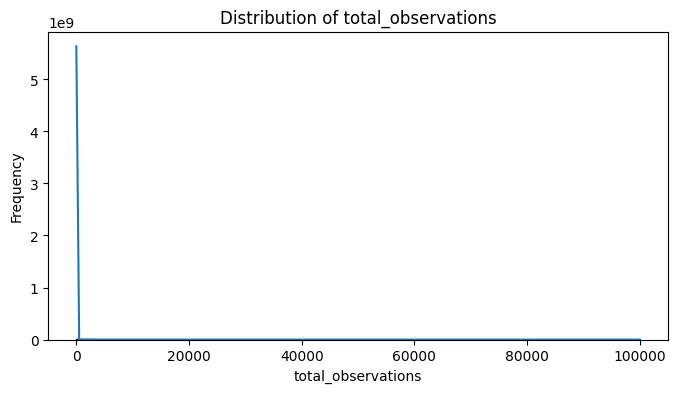

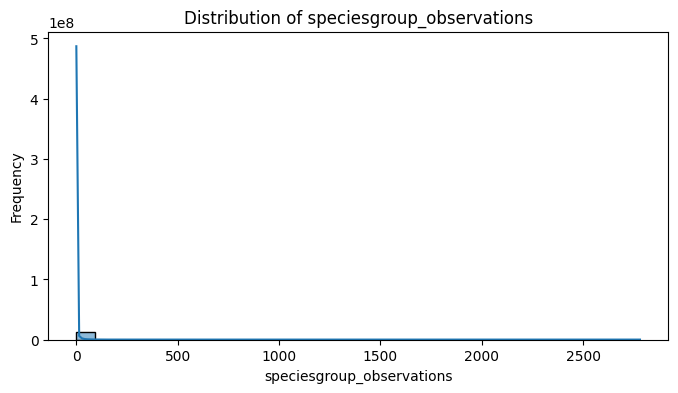

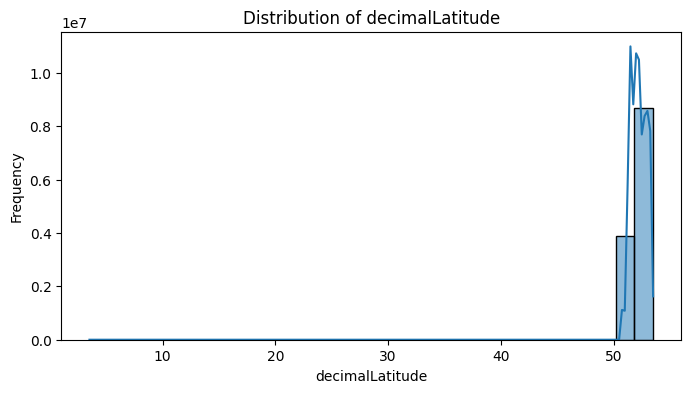

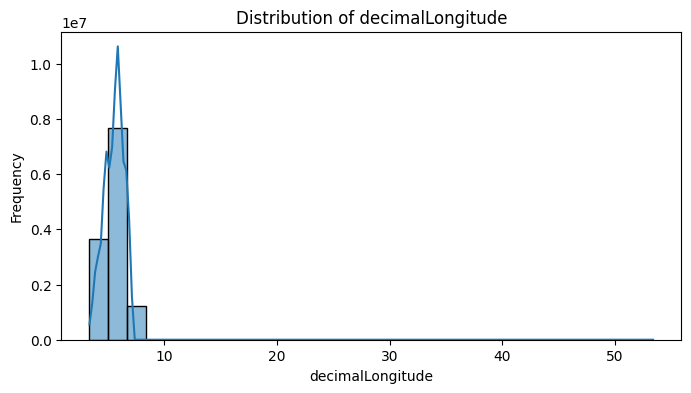

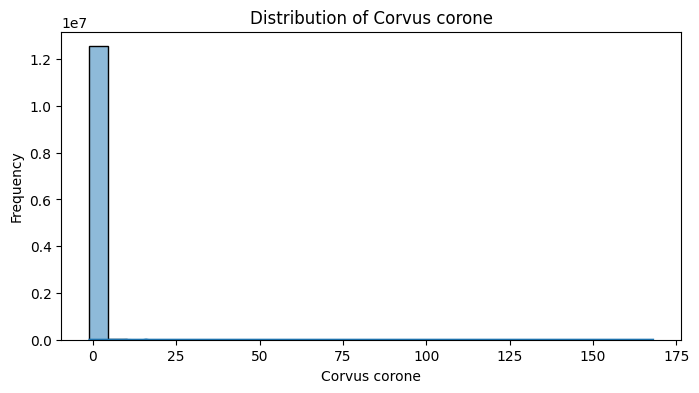

In [35]:
numerical_cols = [
    'total_observations',
    'speciesgroup_observations',
    'decimalLatitude',
    'decimalLongitude',
    'Corvus corone'
]

# Keep only columns that exist
numerical_cols = [col for col in numerical_cols if col in df.columns]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## 2.8 Correlation analysis

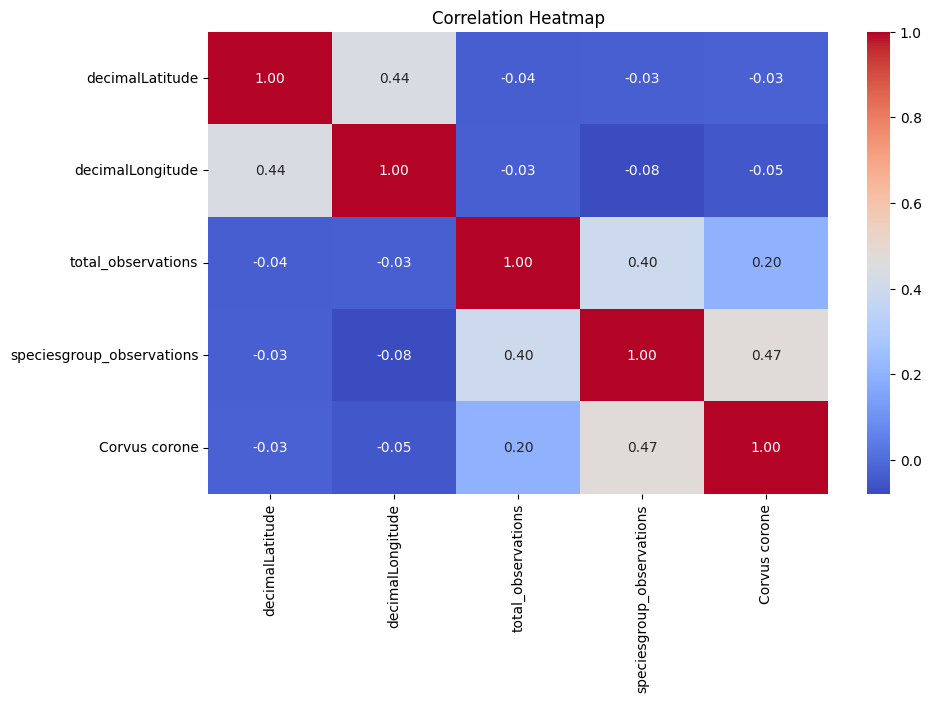

In [36]:
# Make sure Corvus corone is numeric
df["Corvus corone"] = pd.to_numeric(
    df["Corvus corone"],
    errors="coerce"
).fillna(0)

# Numerical columns for correlation
corr_cols = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'Corvus corone'
]

# Create correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

## 2.9 Boxplots and outliers

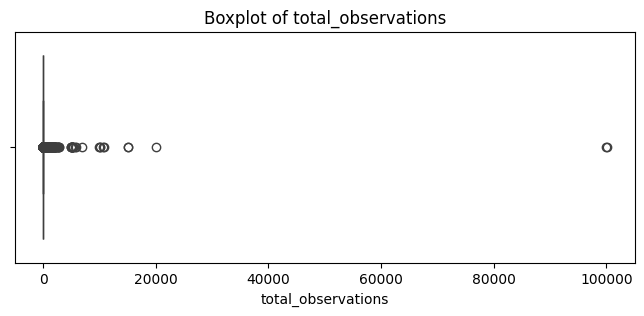

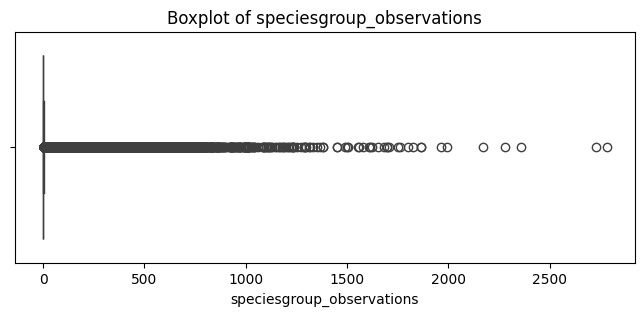

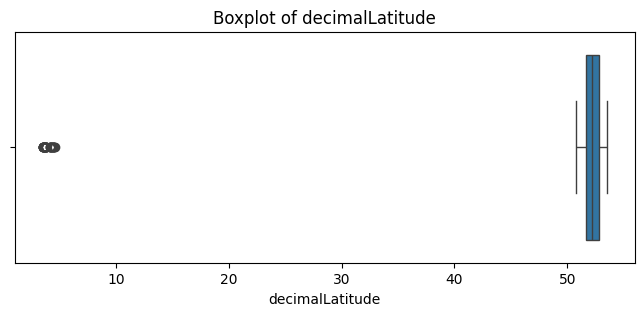

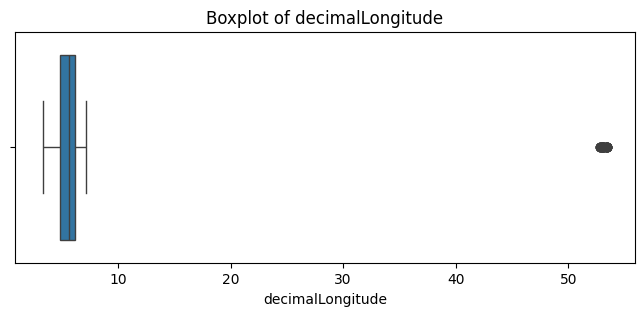

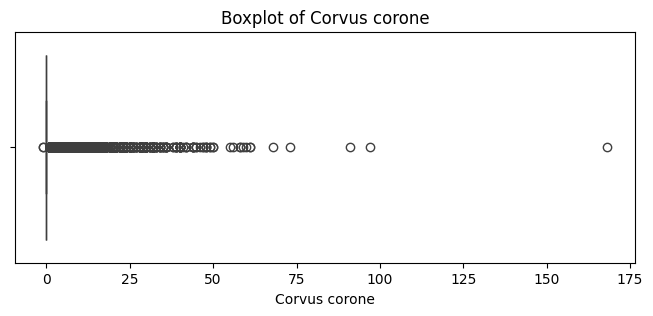

In [37]:
for col in numerical_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

## 2.10 Initial observations

### Initial Observations

- The dataset contains a large number of zero values in the `Corvus corone` count column.
- The binary target is highly imbalanced, with approximately 95% low observation activity and 5% high observation activity.
- Numerical features show heavily skewed distributions and multiple outliers.
- Speciesgroup observations show the strongest correlation with Corvus corone observations.
- Geographic variables show relatively weak correlation with the target variable.
- The dataset may require preprocessing techniques such as scaling, balancing, or transformation before modeling.
- Class imbalance will likely be an important challenge during classification modeling.

## 2.11 Sampling Bias Discussion

The dataset is based on citizen-science observations, which introduces several forms of sampling bias. Observation activity is not evenly distributed across locations or time periods. Urban regions and easily accessible areas may contain significantly more observations than remote locations. Similarly, observation frequency may increase during favorable weather conditions or during periods of higher birdwatching activity.

A value of 0 in the `Corvus corone` count column does not necessarily mean that the species was truly absent from a location. In many cases, the species may simply not have been observed or reported. Therefore, observation effort is an important factor in this project.

Variables such as total_observations and speciesgroup_observations are included to partially capture observer activity and sampling intensity. Weather-related variables may also help explain fluctuations in observation behavior.

## 2.12 Representativity of the Dataset

The dataset provides large-scale observation data across many locations in the Netherlands, which makes it valuable for spatial and temporal analysis. However, the dataset may not fully represent the true ecological distribution of Corvus corone because citizen-science observations depend heavily on human activity and reporting behavior.

Certain regions may contain higher observation densities due to population density, accessibility, or observer interest. Likewise, some time periods may contain more observations than others. As a result, the dataset is likely more representative of observation activity than true species abundance.

Despite these limitations, the dataset remains useful for identifying large-scale observation patterns and building predictive classification models.

## 2.13 Data Quality Assessment

Overall, the dataset quality appears relatively strong. Most columns contain complete data with very few missing values. Geographic coordinates are available for all observations, and the temporal information is consistently formatted.

Several numerical variables contain highly skewed distributions and extreme outliers, particularly in observation-related variables such as total_observations and speciesgroup_observations. These outliers likely reflect differences in observation effort rather than data-entry errors.

The target variable is highly imbalanced, with low observation activity dominating the dataset. This imbalance may affect classification performance and must be considered during model evaluation.

Because the dataset originates from citizen-science observations, some level of noise and reporting uncertainty is expected. However, serious species misidentification is likely limited because Corvus corone is relatively easy to recognize.

## 2.14 Data Understanding Conclusion

The exploratory analysis showed that the dataset is suitable for predictive modeling, but several challenges must be considered. The binary target is highly imbalanced, with most records belonging to the low observation activity class. This means that accuracy alone is not a reliable evaluation metric.

The dataset contains very few missing values and includes useful spatial, temporal, and observation-effort variables. However, because the data comes from citizen-science observations, the dataset may reflect observer activity as much as actual Corvus corone activity.

Spatial visualizations also show that observation density differs between regions. This suggests that sampling bias and representativity should be considered during modeling and evaluation.

----

# 3. Data Preparation

## 3.1 Data cleaning

We perform initial cleaning steps before preprocessing:

1. **Convert `eventDate` to datetime** - enables extraction of temporal features.
2. **Convert `Corvus corone` to numeric** - this is the observation count used to create the low/high activity target.
3. **Create `target_binary`** - 0 = low observation activity, 1 = high observation activity using the current threshold `Corvus corone > 0`.
4. **Handle missing values** - only 1 missing value was found earlier in `total_observations` (0.0% of data). We drop rows with missing values after conversion.
5. **Check for duplicate rows** - duplicate records are removed if present.

In [38]:
# Work on a copy so the original dataframe remains available for reference
df_clean = df.copy()

# Convert eventDate to datetime
df_clean['eventDate'] = pd.to_datetime(df_clean['eventDate'], errors='coerce')

# Convert Corvus corone observation counts to numeric
df_clean['Corvus corone'] = pd.to_numeric(df_clean['Corvus corone'], errors='coerce').fillna(0)

# Create preliminary binary target (0 = low activity, 1 = high activity)
df_clean['target_binary'] = (df_clean['Corvus corone'] > 0).astype(int)

#check missing values
print("Missing values before cleaning:")
print(df_clean.isna().sum())

# drop rows with missing values after type conversion
rows_before = len(df_clean)
df_clean = df_clean.dropna().copy()

print(f"\nRows removed: {rows_before - len(df_clean)}")
print(f"Rows after dropping: {len(df_clean)}")

# Check for duplicate rows
duplicates = df_clean.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found.")
else:
    df_clean = df_clean.drop_duplicates().copy()
    print(f"Dropped {duplicates} duplicates.")

Missing values before cleaning:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           1
speciesgroup_observations    0
Corvus corone                0
target_binary                0
dtype: int64

Rows removed: 1
Rows after dropping: 12558785

Duplicate rows: 0
No duplicate rows found.


## 3.2 Feature engineering

From `eventDate` we extract useful temporal features that may influence observation activity: year, month, day of year, season, and weekend flag.

In [39]:
# Extract temporal features from eventDate
df_clean['year'] = df_clean['eventDate'].dt.year
df_clean['month'] = df_clean['eventDate'].dt.month
df_clean['day_of_year'] = df_clean['eventDate'].dt.dayofyear
df_clean['weekend'] = (df_clean['eventDate'].dt.dayofweek >= 5).astype(int)

# Define seasons (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df_clean['season'] = df_clean['month'].apply(get_season)

# Drop original date column after extracting temporal features
df_clean = df_clean.drop(columns=['eventDate'])

# Verify new features
df_clean[['year', 'month', 'day_of_year', 'weekend', 'season']].head()

,year,month,day_of_year,weekend,season
0,2010,1,1,0,0
1,2010,1,2,1,0
2,2010,1,3,1,0
3,2010,1,4,0,0
4,2010,1,5,0,0


## 3.3 Encoding

No one-hot encoding is needed at this stage. After feature engineering, all features are numeric. `season` is encoded as an ordinal seasonal category, and `weekend` is a binary flag. The model target is `target_binary`; the raw `Corvus corone` count should not be used as an input feature when predicting that target.

In [40]:
# No one-hot encoding needed for the current feature set
categorical_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
categorical_cols

[]

## 3.4 Scaling

Numerical predictors have different scales. To avoid data leakage, the scaler should be fitted only on the training data after the train-test split in section 4. Here we define the columns that should be scaled later.

In [41]:
# Columns to scale later after train-test split
num_cols_to_scale = [
    'total_observations',
    'speciesgroup_observations',
    'decimalLatitude',
    'decimalLongitude',
    'year',
    'month',
    'day_of_year'
]

# Keep a model-ready dataframe with engineered features but without fitted scaling yet
df_model_ready = df_clean.copy()

df_model_ready[num_cols_to_scale].describe()

,total_observations,speciesgroup_observations,decimalLatitude,decimalLongitude,year,month,day_of_year
count,1.255878e+07,1.255878e+07,1.255878e+07,1.255878e+07,1.255878e+07,1.255878e+07,1.255878e+07
mean,8.056834e+00,4.314007e+00,5.222995e+01,5.532893e+00,2.017500e+03,6.522917e+00,1.831249e+02
std,4.821959e+01,1.610559e+01,6.645900e-01,8.778675e-01,4.609711e+00,3.448710e+00,1.054388e+02
min,0.000000e+00,0.000000e+00,3.500000e+00,3.350000e+00,2.010000e+03,1.000000e+00,1.000000e+00
25%,0.000000e+00,0.000000e+00,5.170000e+01,4.900000e+00,2.014000e+03,4.000000e+00,9.200000e+01
50%,1.000000e+00,0.000000e+00,5.220000e+01,5.650000e+00,2.018000e+03,7.000000e+00,1.830000e+02
75%,6.000000e+00,2.000000e+00,5.280000e+01,6.200000e+00,2.022000e+03,1.000000e+01,2.740000e+02
max,1.000390e+05,2.781000e+03,5.350000e+01,5.340000e+01,2.026000e+03,1.200000e+01,3.660000e+02


----

# 4. Modeling

## 4.1 Train-test split

## 4.2 Classification model

## 4.3 Model results

## 4.4 Metrics

----

# 5. Evaluation

## 5.1 Results vs success criteria

The success criteria defined earlier in the project will be used to evaluate the model results.

The model will be evaluated based on:
- AUC-ROC score
- F1-score compared to the majority-class baseline
- Balanced performance between both target classes
- Performance on unseen test data

This section will be completed after the first model results are available.

## 5.2 Limitations

Several limitations should be considered when interpreting the project results.

First, the dataset is based on citizen-science observations. This means that observations are influenced by human activity, accessibility, and reporting behaviour.

Second, a value of 0 does not always mean that Corvus corone was truly absent. It may also mean that the species was not observed or reported.

Third, the dataset is highly imbalanced, with many more low-activity records than high-activity records. This may make classification more difficult.

Finally, the weather data currently comes from one KNMI weather station, De Bilt. This may not fully represent local weather conditions across the Netherlands.

## 5.3 Next steps

The next steps are to complete the modeling and evaluation phases.

Weather data should be merged with the observation dataset and used as additional input features. Additional feature engineering may also be useful, especially for weather variables or cyclic temporal patterns.

After that, classification models can be trained and compared using AUC-ROC, F1-score, precision, and recall. The results should then be compared with the predefined success criteria.

Finally, the team should interpret what is working, what is not working, and how limitations such as sampling bias and class imbalance affect the model results.